In [2]:
import os
os.environ["TOKENIZERS_PARALLELISM"] = "true"
os.environ['CUDA_HOME'] = '/home/jovyan/vasiliev/notebooks/Show-o/cuda_fake'
# os.environ['CUDA_VISIBLE_DEVICES'] = '3'|

In [3]:
from PIL import Image
from tqdm import tqdm
import numpy as np
import torch
import torch.nn as nn
from transformers import AutoTokenizer
from models import Showo
from training.prompting_utils import UniversalPrompting, create_attention_mask_predict_next
from training.utils import get_config
import json
import argparse
from PIL import Image
import numpy as np
from omegaconf import OmegaConf
from models.clip_encoder import CLIPVisionTower
from transformers import CLIPImageProcessor
from llava import conversation as conversation_lib
from omegaconf import OmegaConf
from copy import deepcopy
from collections import defaultdict
import matplotlib.pyplot as plt
from typing import List, Dict, Optional
import torch
from omegaconf import OmegaConf
from models.modeling.modeling_showo import Showo
from models.phi import PhiMLP, PhiConfig
from models.moe_gates import GShardGate


conversation_lib.default_conversation = conversation_lib.conv_templates["phi1.5"]
STATS_TYPES = ['max_abs', 'min_abs', 'var']

/home/jovyan/vasiliev/notebooks/Show-o/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


[2025-10-17 14:18:22,074] [INFO] [real_accelerator.py:203:get_accelerator] Setting ds_accelerator to cuda (auto detect)
 [WARNING]  async_io requires the dev libaio .so object and headers but these were not found.
 [WARNING]  async_io: please install the libaio-dev package with apt
 [WARNING]  If libaio is already installed (perhaps from source), try setting the CFLAGS and LDFLAGS environment variables to where it can be found.
 [WARNING]  Please specify the CUTLASS repo directory as environment variable $CUTLASS_PATH


/usr/bin/ld: cannot find -laio: No such file or directory
collect2: error: ld returned 1 exit status


 [WARNING]  sparse_attn requires a torch version >= 1.5 and < 2.0 but detected 2.2
 [WARNING]  using untested triton version (2.2.0), only 1.0.0 is known to be compatible


In [4]:
from inference_mmu import run_mmu
from inference_t2i import run_t2i

In [5]:
config = OmegaConf.load('configs/showo_demo_w_clip_vit_512x512.yaml')

In [6]:
class MoE(nn.Module):
    """Mixture of Experts слой"""
    def __init__(self, num_experts, hidden_size, top_k, config: PhiConfig):
        super().__init__()
        self.gate = GShardGate(hidden_size, num_experts, 1, top_k)
        self.num_experts = num_experts
        self.hidden_size = hidden_size
        self.top_k = top_k

        self.experts = nn.ModuleList(
            [PhiMLP(config) for _ in range(self.num_experts)]
        )

        self.alpha = nn.Parameter(torch.randn(self.num_experts))

    def forward(self, hidden_states):
        batch_size, seq_len, hidden_size = hidden_states.shape

        # Reshape to (batch_size * seq_len, hidden_size) for gate processing
        hidden_states_flat = hidden_states.view(-1, hidden_size)

        gate_idx, gate_score = self.gate(hidden_states_flat)
        # gate_idx: (batch_size * seq_len, top_k)
        # gate_score: (batch_size * seq_len, top_k)

        output_flat = torch.zeros(
            batch_size * seq_len, hidden_size, device=hidden_states.device
        )

        for k in range(self.top_k):
            expert_indices = gate_idx[:, k]  # (batch_size * seq_len,)
            weights = gate_score[:, k]  # (batch_size * seq_len,)

            for expert_id in range(self.num_experts):
                mask = expert_indices == expert_id

                if mask.any():
                    expert_input = hidden_states_flat[mask]
                    expert_output = self.experts[expert_id](expert_input)
                    weight = weights[mask] * self.alpha[expert_id]
                    output_flat[mask] += expert_output * weight.unsqueeze(-1)

        # Reshape back to (batch_size, seq_len, hidden_size)
        output = output_flat.view(batch_size, seq_len, hidden_size)
        return output

In [7]:
def get_model(config):
    model = Showo.from_pretrained(config.model.showo.pretrained_model_path)
    model.eval()
    return model

def get_patched_moe_model(config):
    model = get_model(config)
    print("Патчим модель с MoE...")
    config_phi = model.showo.config
    for layer_idx, layer in enumerate(model.showo.model.layers):
        if hasattr(layer, 'mlp'):
            print(f"Заменяем MLP в слое {layer_idx}")
            moe_layer = MoE(
                num_experts=4,
                hidden_size=config_phi.hidden_size,
                top_k=2,
                config=config_phi
            )
            layer.mlp = moe_layer
    
    model.eval()
    return model

In [8]:
# moe_model = get_patched_moe_model(config)

In [9]:
# moe_model

In [10]:
class Stats:
    def __init__(self, device: str = "cpu"):
        self._lists: Dict[str, List[torch.Tensor]] = {name: [] for name in STATS_TYPES}
        self.device = device

    def append(self, name: str, tensor: torch.Tensor) -> None:
        if name not in self._lists:
            raise KeyError(f"Unknown stat name '{name}'")
        self._lists[name].append(tensor.detach().to('cpu'))

    def append_many(self, stats: Dict[str, torch.Tensor]) -> None:
        for k, v in stats.items():
            if v is None:
                continue
            self.append(k, v)

    @torch.no_grad()
    def collect_from_tensor(self, out: torch.Tensor, sparsity_eps) -> None:
        max_abs = out.abs().amax(dim=1, keepdim=False)           # (batch_size,)
        var = out.var(dim=1, unbiased=False, keepdim=False)      # (batch_size,)
        sparsity = (out.abs() < sparsity_eps).float().mean(dim=1, keepdim=False)  # (batch_size,)
        min_abs = out.abs().amin(dim=1, keepdim=False)   
        # sparsity = out.abs().amin(dim=1, keepdim=False)   
        self.append("max_abs", max_abs)
        self.append("var", var)
        # self.append("sparsity", sparsity)
        self.append("min_abs", min_abs)

    def cat(self, name: str) -> Optional[torch.Tensor]:
        lst = self._lists.get(name)
        if not lst:
            return None
        return torch.cat(lst, dim=0)
    
    def clear(self) -> None:
        for k in list(self._lists.keys()):
            self._lists[k].clear()

    def __repr__(self):
        s = ", ".join(f"{k}: {len(v)}" for k, v in self._lists.items())
        return f"Stats({s})"

In [11]:
class LayerOutputRecorder:
    def __init__(self, device='cuda', sparsity_eps=1e-2):
        # теперь по умолчанию создаётся Stats() для каждого ключа
        self.outputs = defaultdict(lambda: Stats(device=device))
        self.inputs_shapes = defaultdict(list)
        self.handles = []
        self.device = device
        self.sparsity_eps = sparsity_eps

    def build_hook_fn(self, name):
        def hook_fn(module, input_, output):
            with torch.no_grad():
                out = output.detach()
                self.outputs[name].collect_from_tensor(out, sparsity_eps=self.sparsity_eps)
                self.inputs_shapes[name].append(input_[0].shape)
        return hook_fn

    def register_hook(self, module_name, module):
        handle = module.register_forward_hook(self.build_hook_fn(module_name))
        self.handles.append(handle)

    def register_hooks(self, modules: list[tuple[str, torch.nn.Module]]) -> None:
        for module_name, module in modules:
            self.register_hook(module_name, module)

    def remove_hooks(self):
        for handle in self.handles:
            handle.remove()
        self.handles = []

    def clear(self):
        for stats in self.outputs.values():
            stats.clear()
        self.outputs.clear()
        self.inputs_shapes.clear()
        torch.cuda.empty_cache()

In [12]:
def get_target_layers(model) -> list[tuple[str, torch.nn.Module]]:
    layers = []
    for name, module in model.named_modules():
        if isinstance(module, nn.Linear):
            layers.append((name, module))
    return layers

In [13]:
model_t2i = get_model(config)
model_mmu = get_model(config)
# model_mmu = m

The config attributes {'mask_token_id': 58497} were passed to Showo, but are not expected and will be ignored. Please verify your config.json configuration file.
/home/jovyan/vasiliev/notebooks/Show-o/.venv/lib/python3.11/site-packages/huggingface_hub/file_download.py:1132: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


attention implementation:  sdpa


/home/jovyan/vasiliev/notebooks/Show-o/models/modeling/modeling_showo.py:52: FutureWarning: Accessing config attribute `w_clip_vit` directly via 'Showo' object attribute is deprecated. Please access 'w_clip_vit' over 'Showo's config object instead, e.g. 'unet.config.w_clip_vit'.
  if self.w_clip_vit:
The config attributes {'mask_token_id': 58497} were passed to Showo, but are not expected and will be ignored. Please verify your config.json configuration file.


attention implementation:  sdpa


In [14]:
# list(model_mmu.named_modules())

In [15]:
target_layers_t2i = get_target_layers(model_t2i)
activations_recorder_t2i = LayerOutputRecorder()
activations_recorder_t2i.register_hooks(target_layers_t2i)

In [16]:
target_layers_mmu = get_target_layers(model_mmu)
activations_recorder_mmu = LayerOutputRecorder()
activations_recorder_mmu.register_hooks(target_layers_mmu)

In [17]:
# mode=t2i dataset.params.validation_prompts_file=validation_prompts/showoprompts.txt batch_size=1

In [18]:
# uv run inference_t2i.py config=configs/showo_demo_w_clip_vit_512x512.yaml mode=t2i dataset.params.validation_prompts_file=validation_prompts/showoprompts.txt batch_size=1

In [19]:
# uv run inference_mmu.py config=configs/showo_demo_w_clip_vit_512x512.yaml max_new_tokens=100 mmu_image_root=./mmu_validation

In [20]:
cfg = OmegaConf.load("configs/showo_demo_w_clip_vit_512x512.yaml")
# cfg.batch_size = 1
cfg.max_new_tokens = 100

cfg_mmu = deepcopy(cfg)
cfg_t2i = deepcopy(cfg)


cfg_t2i.dataset.params.validation_prompts_file="validation_prompts/text2image_prompts.txt"
cfg_t2i.mode = "t2i"
cfg_mmu.mmu_image_root = "./train2017"
cfg_mmu.questions_path = "./training/questions.json"
cfg_mmu.samples_count = 200
cfg_mmu.device = "cuda:0"
cfg_t2i.device = "cuda:0"

In [21]:
def get_activations(recorder, stat: str = "max_abs", layers: list[int] = None):
    if stat not in STATS_TYPES:
        raise ValueError(f"stat must be one of {STATS_TYPES}, got {stat}")
    if layers is None:
        layers = list(range(24))
    layer_names = []
    acts_list = []

    for ind in tqdm(layers, desc=f"collecting {stat}"):
        layer_name = f"showo.model.layers.{ind}.mlp.fc2"
        if layer_name not in recorder.outputs:
            continue

        stats_obj: Stats = recorder.outputs[layer_name]
        t = stats_obj.cat(stat)
        if t is None:
            continue

        t = t.detach().cpu().flatten()
        if t.numel() == 0:
            continue

        layer_names.append(layer_name)
        acts_list.append(t)

    return layer_names, acts_list


def print_stat_boxplots(recorder, stat: str = "max_abs", layers: list[int] = None,
                        figsize=(14,6), showfliers=False):
    layer_names, acts_list = get_activations(recorder, stat=stat, layers=layers)

    if len(acts_list) == 0:
        print("No activations collected for the requested layers/stat.")
        return

    data = [a.numpy() if isinstance(a, torch.Tensor) else np.asarray(a) for a in acts_list]
    plt.figure(figsize=figsize)
    labels = [ln.split(".")[3] if len(ln.split(".")) > 3 else ln for ln in layer_names]
    plt.boxplot(data, labels=labels, showfliers=showfliers)
    plt.xticks(rotation=45, ha='right')
    plt.ylabel(stat)
    plt.title(f"Boxplots of '{stat}' across layers ({len(data)} layers)")
    plt.tight_layout()
    plt.show()

In [22]:
def print_all_stats_boxplots(recorder, layers: list[int] = None, figsize=(18,6), showfliers=False):
    # Нормализуем в словарь
    if not isinstance(recorder, dict):
        recorders = {'': recorder}
    else:
        recorders = recorder
    
    stats = list(STATS_TYPES)
    n_stats = len(stats)
    n_recorders = len(recorders)
    
    # 2 строки: boxplots и средние
    fig, axes = plt.subplots(2, n_stats, figsize=(figsize[0], figsize[1] * 1.5), sharey=False)
    if n_stats == 1:
        axes = axes.reshape(-1, 1)
    
    colors = plt.cm.Set2(range(n_recorders))
    
    for col, stat in enumerate(stats):
        ax_box = axes[0, col]
        ax_mean = axes[1, col]
        
        # Собираем данные от всех рекордеров
        recorders_data = {}
        layer_names_all = None
        
        for rec_name, rec in recorders.items():
            layer_names, acts_list = get_activations(rec, stat=stat, layers=layers)
            if len(acts_list) == 0:
                continue
            
            if layer_names_all is None:
                layer_names_all = layer_names
            
            data = [a.numpy() if isinstance(a, torch.Tensor) else np.asarray(a) for a in acts_list]
            recorders_data[rec_name] = data
        
        if len(recorders_data) == 0:
            ax_box.text(0.5, 0.5, f"No data", ha='center', va='center')
            ax_box.set_title(stat)
            ax_mean.text(0.5, 0.5, f"No data", ha='center', va='center')
            continue
        
        # === ВЕРХНИЙ РЯД: Boxplots ===
        n_layers = len(next(iter(recorders_data.values())))
        width = 0.8 / n_recorders
        
        legend_patches = []
        for i, (rec_name, data) in enumerate(recorders_data.items()):
            positions = [j + 1 + (i - n_recorders/2 + 0.5) * width for j in range(n_layers)]
            bp = ax_box.boxplot(data, positions=positions, widths=width*0.9, 
                               showfliers=showfliers, patch_artist=True)
            for patch in bp['boxes']:
                patch.set_facecolor(colors[i])
            
            # Создаем патч для легенды
            if rec_name:
                from matplotlib.patches import Patch
                legend_patches.append(Patch(facecolor=colors[i], label=rec_name))
        
        # Метки по оси X
        labels = [ln.split(".")[3] if len(ln.split("."))>3 else ln for ln in layer_names_all]
        ax_box.set_xticks(range(1, n_layers + 1))
        ax_box.set_xticklabels(labels, rotation=45, ha='right')
        ax_box.set_title(stat)
        
        if len(legend_patches) > 0:
            ax_box.legend(handles=legend_patches)
        
        # === НИЖНИЙ РЯД: Графики средних ===
        for i, (rec_name, data) in enumerate(recorders_data.items()):
            means = [d.mean() for d in data]
            x = range(1, len(means) + 1)
            ax_mean.plot(x, means, marker='o', color=colors[i], 
                        label=rec_name if rec_name else None)
        
        ax_mean.set_xticks(range(1, n_layers + 1))
        ax_mean.set_xticklabels(labels, rotation=45, ha='right')
        ax_mean.set_ylabel("Mean")
        ax_mean.grid(True, alpha=0.3)
        
        if len(legend_patches) > 0:
            ax_mean.legend()
    
    plt.tight_layout()
    plt.show()

In [23]:
run_mmu(cfg_mmu, model_mmu)

Working with z of shape (1, 13, 16, 16) = 3328 dimensions.
Look-up free quantizer with codebook size: 8192


  0%|          | 0/200 [00:00<?, ?it/s]/home/jovyan/vasiliev/notebooks/Show-o/inference_mmu.py:159: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  input_ids = torch.tensor(input_ids).to(device).squeeze(0)
  0%|          | 1/200 [00:02<08:37,  2.60s/it]

 A red double decker bus is driving down a street with other vehicles, including a silver car and a truck.


  1%|          | 2/200 [00:04<06:40,  2.02s/it]

 A man in a white shirt is sitting in a chair and using a laptop.


...

100%|█████████▉| 199/200 [08:20<00:01,  1.36s/it]

 x


100%|██████████| 200/200 [08:21<00:00,  2.51s/it]

 A dog is standing on a surfboard in the water, with a person nearby.


=== Multimodal Understanding Results ===

Image 1: 000000147328.jpg
Response: User: s
 Answer :  A red double decker bus is driving down a street with other vehicles, including a silver car and a truck.

--------------------------------------------------

Image 2: 000000414738.jpg
Response: User: e
 Answer :  A man in a white shirt is sitting in a chair and using a laptop.

--------------------------------------------------

Image 3: 000000281563.jpg
Response: User:  
 Answer :  A bowl of pasta with broccoli and cheese.

--------------------------------------------------

Image 4: 000000063879.jpg
Response: User: t
 Answer :  Tennis player in a blue dress and white hat.

--------------------------------------------------

Image 5: 000000531349.jpg
Response: User: i
 Answer :  A man with a mustache is holding a knife in his hand.

--------------------------------------------------

Image 6: 000000340329.jpg
Response: User: e
 Answer :  The zebra is standing in a pen with a fence around 

collecting var: 100%|██████████| 24/24 [00:00<00:00, 37.78it/s]


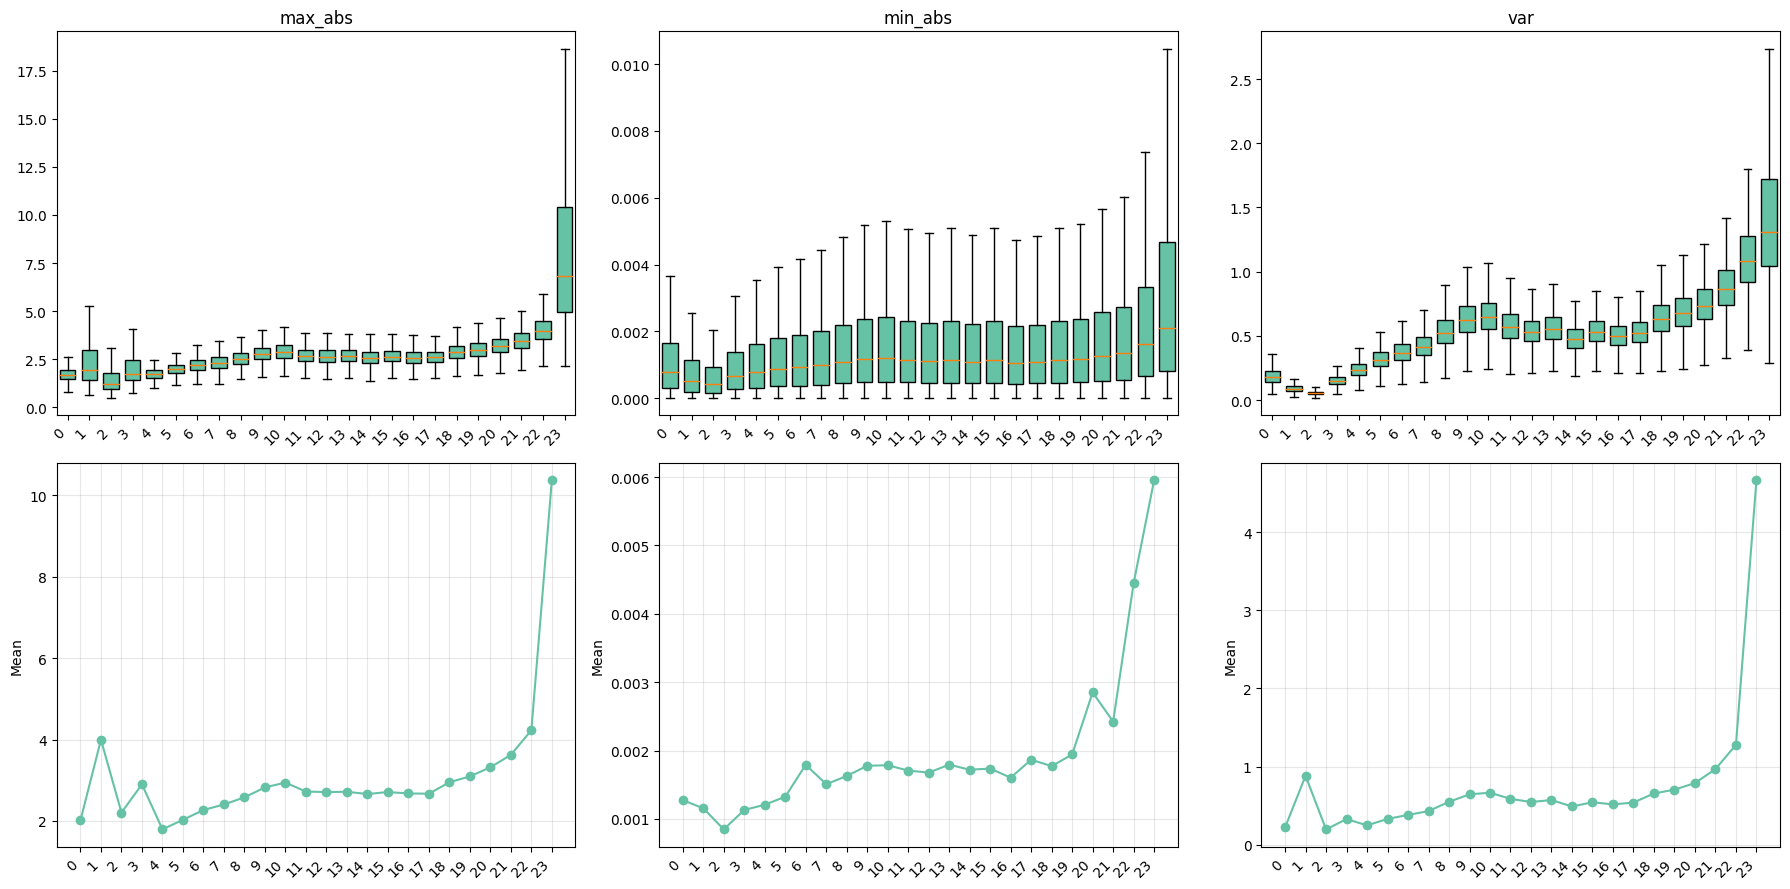

In [24]:
print_all_stats_boxplots(activations_recorder_mmu)

In [25]:
run_t2i(cfg_t2i, model_t2i)

Saving images to: show-o-demo/inference_t2i_20251017_143803
Working with z of shape (1, 13, 16, 16) = 3328 dimensions.
Look-up free quantizer with codebook size: 8192


100%|██████████| 1/1 [00:28<00:00, 28.31s/it]

Saved 8 text-to-image results to show-o-demo/inference_t2i_20251017_143803


collecting var: 100%|██████████| 24/24 [00:00<00:00, 643.31it/s]


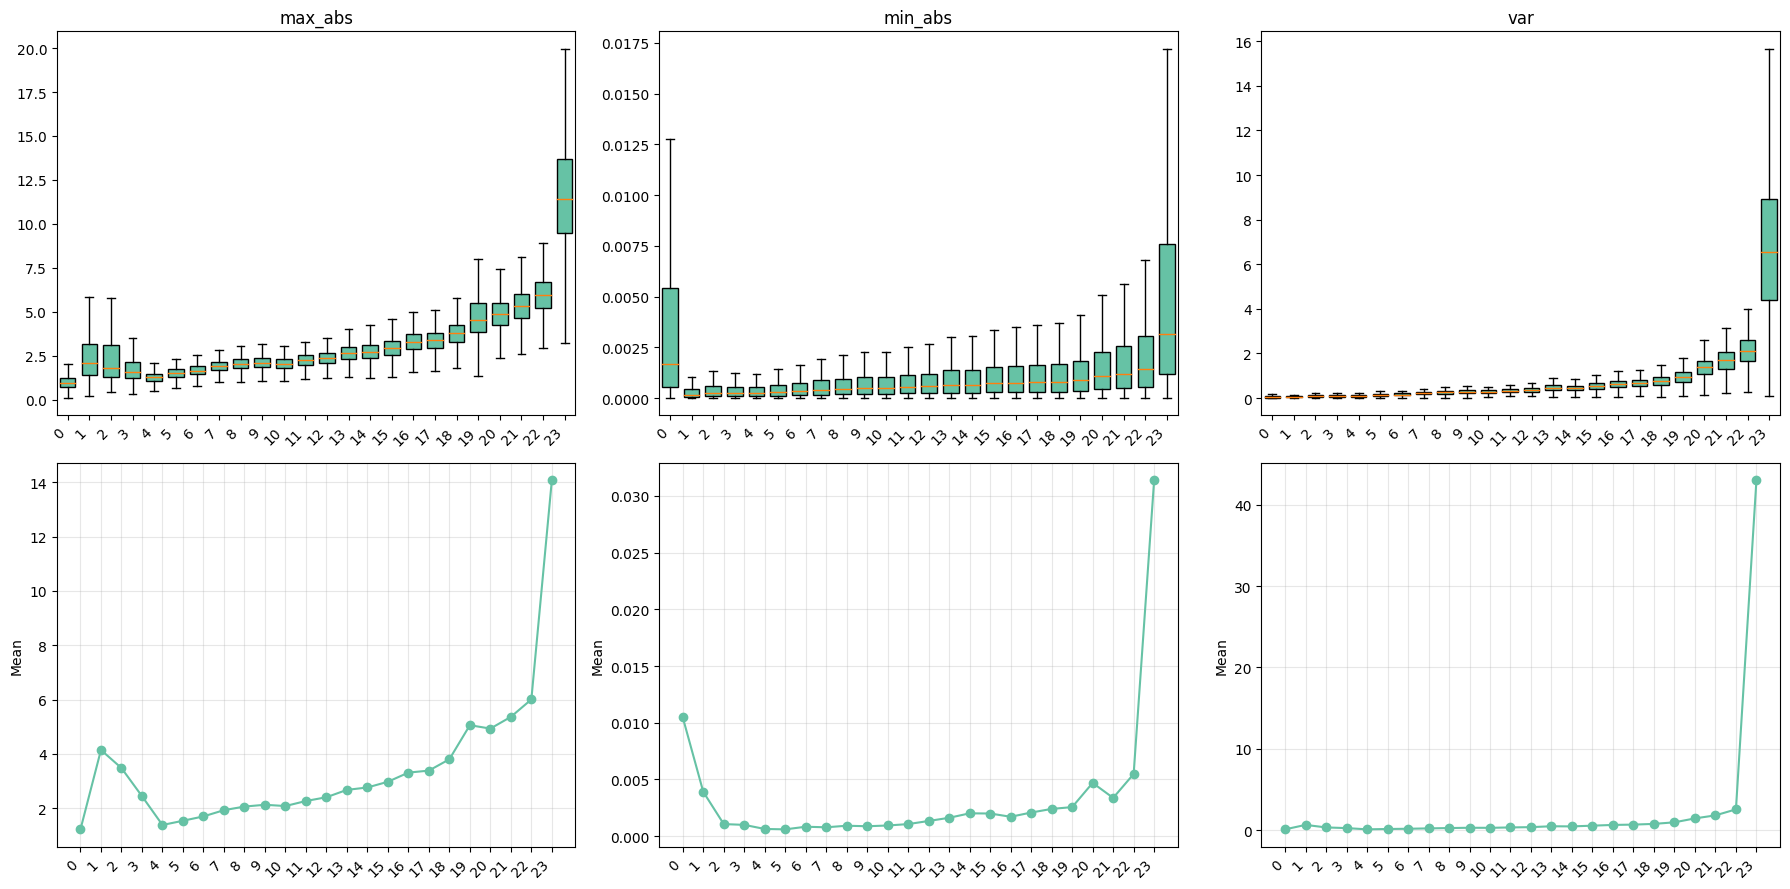

In [26]:
print_all_stats_boxplots(activations_recorder_t2i)

collecting var: 100%|██████████| 24/24 [00:00<00:00, 927.56it/s]


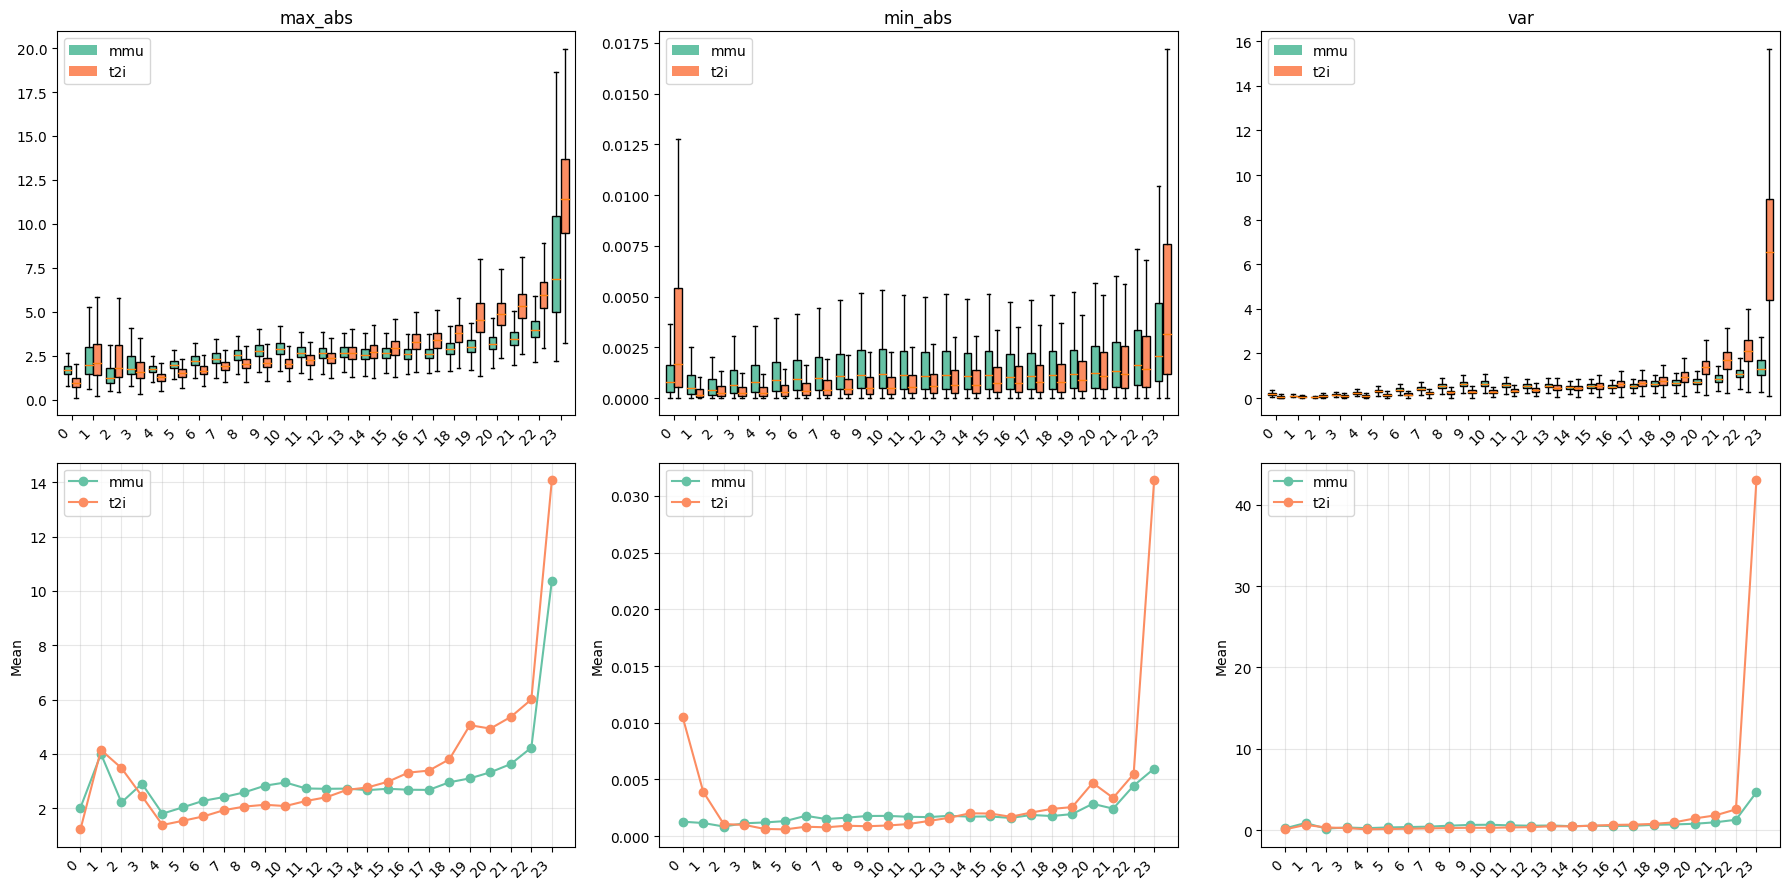

In [27]:
print_all_stats_boxplots({'mmu': activations_recorder_mmu, 't2i': activations_recorder_t2i})